In [2]:
import numpy as np
from matplotlib import pyplot as plt
import os
import pandas as pd
import re

plt.rcParams.update({'font.size': 8})

In [3]:
df = pd.read_csv('../camels_info/camels_parameters.csv')
df

,Name,Omega_m,sigma_8,A_SN1,A_AGN1,A_SN2,A_AGN2,seed
0,LH_0,0.3090,0.9790,3.11234,1.12194,0.66850,0.53182,0
1,LH_1,0.3026,0.9394,3.42001,3.96137,1.03311,1.16070,1
2,LH_2,0.4282,0.7530,0.70613,0.37423,1.96292,0.62720,2
3,LH_3,0.1906,0.6286,1.60882,0.39887,0.86634,0.86634,3
4,LH_4,0.1382,0.6874,1.19914,0.27586,0.82188,0.91700,4
...,...,...,...,...,...,...,...,...
1092,CV_26,0.3000,0.8000,1.00000,1.00000,1.00000,1.00000,27
1093,EX_0,0.3000,0.8000,1.00000,1.00000,1.00000,1.00000,13560
1094,EX_1,0.3000,0.8000,1.00000,100.00000,1.00000,1.00000,13560
1095,EX_2,0.3000,0.8000,100.00000,1.00000,1.00000,1.00000,13560


In [4]:
df.columns

Index(['Name', 'Omega_m', 'sigma_8', 'A_SN1', 'A_AGN1', 'A_SN2', 'A_AGN2',
       'seed'],
      dtype='object')

In [5]:
out_dir = "../power_spectra/CO/20230313_no_std/"

def get_files_for_para(n):
    fils = list(map(lambda fil: fil[:-4], \
               (filter(lambda fil: f"1P_{n}" in fil, os.listdir(out_dir)))))
    sorter_1P_fils = lambda filname: int(filname.split('_')[-1].replace('n', '-'))
    return sorted(fils, key=sorter_1P_fils)

get_files_for_para(1)

['1P_1_n5',
 '1P_1_n4',
 '1P_1_n3',
 '1P_1_n2',
 '1P_1_n1',
 '1P_1_0',
 '1P_1_1',
 '1P_1_2',
 '1P_1_3',
 '1P_1_4',
 '1P_1_5']

In [6]:
def make_plots_for_all_paras(snap_index=31):
    fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(10, 10), sharex=True, sharey=True)
    for n, ax in zip(range(1, 7), axs.flatten()):
        fils = get_files_for_para(n)
        para = df.columns[n]
        for fil in fils:
            with np.load(out_dir + fil + ".npz", allow_pickle=True) as data:
                curve = data['curves'].item()[snap_index]
                redshift = data['redshifts'].item()[snap_index]
                k = data['ks'].item()[snap_index]
            ax.plot(k, curve, ls="--", marker="x", label=df[df["Name"] == fil][para].iloc[0])
        # ax.set_ylim([1e0, 6e3])
        ax.set_xlim([1.5e-1, 2.5e1])
        ax.set_title(f"varying {para}, snap {snap_index} at redshift {redshift:.5f}")
        ax.loglog()
        ax.grid()
        ax.axhline(1, ls="--", color="black")
        ax.legend(fontsize=6, bbox_to_anchor=(1.0, 0.5), loc="center left")
    plt.show()
    plt.close()

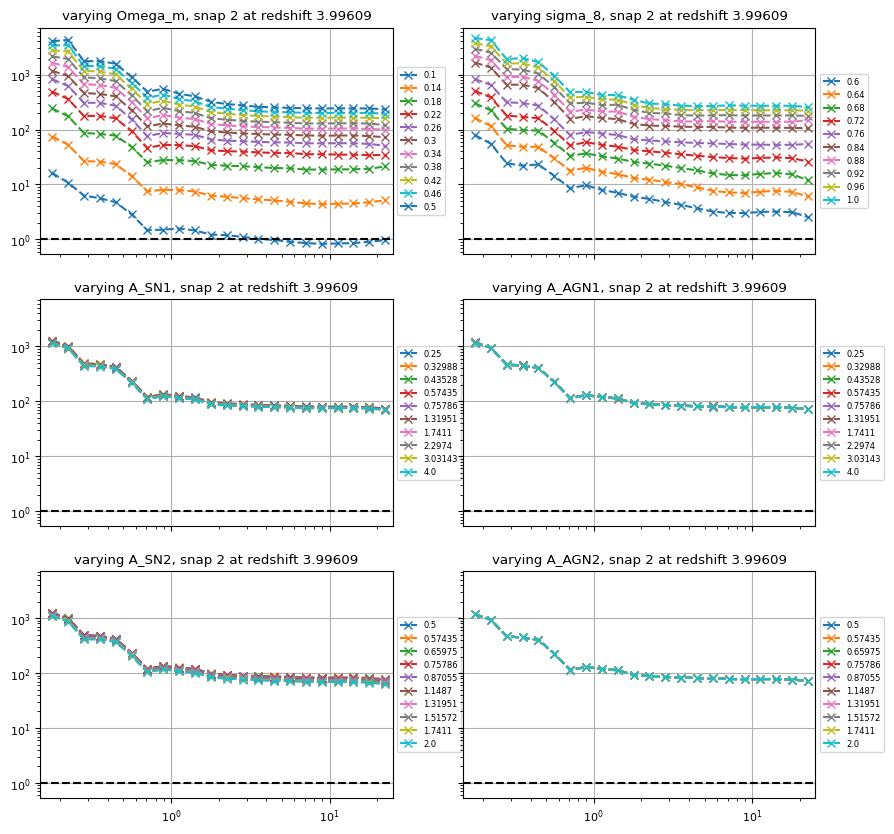

In [7]:
make_plots_for_all_paras(snap_index=2)

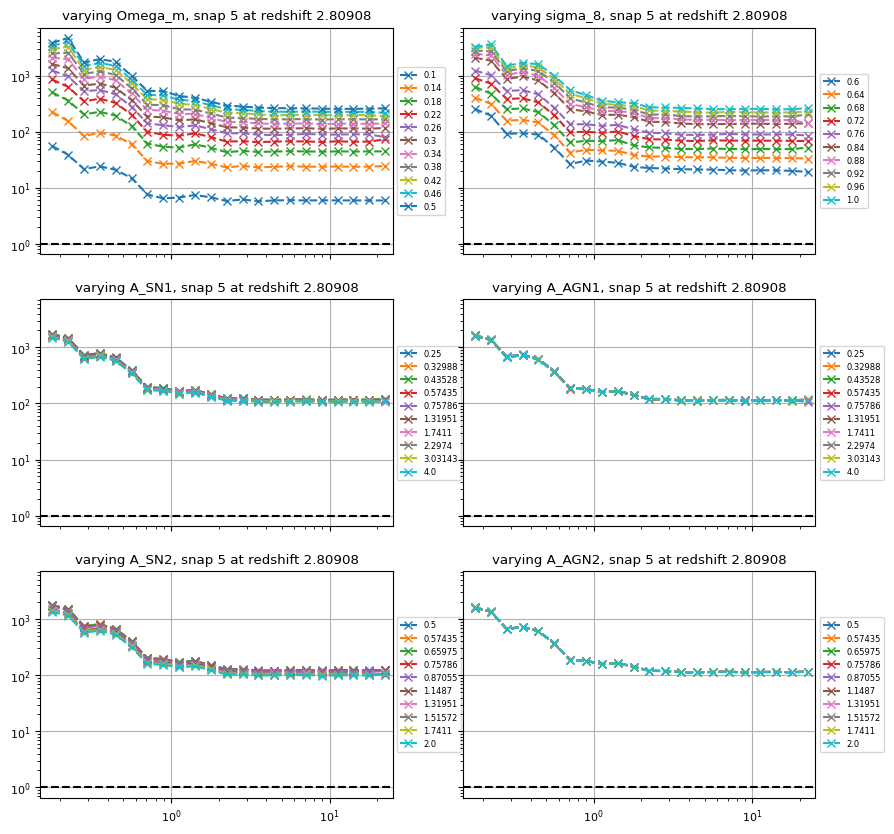

In [8]:
make_plots_for_all_paras(snap_index=5)

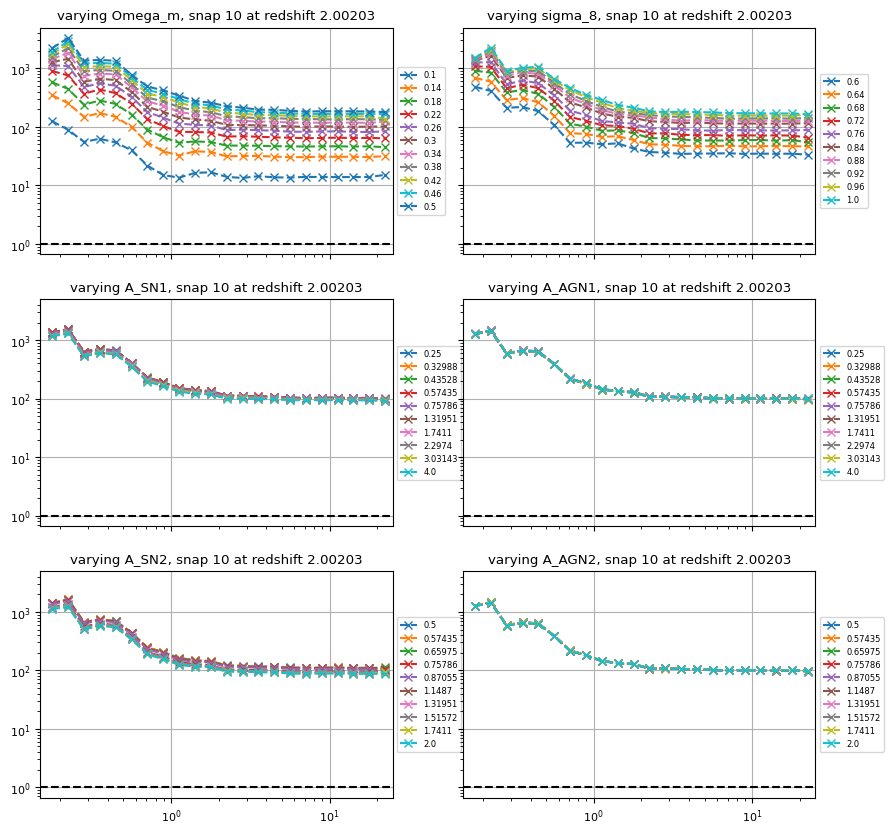

In [9]:
make_plots_for_all_paras(snap_index=10)

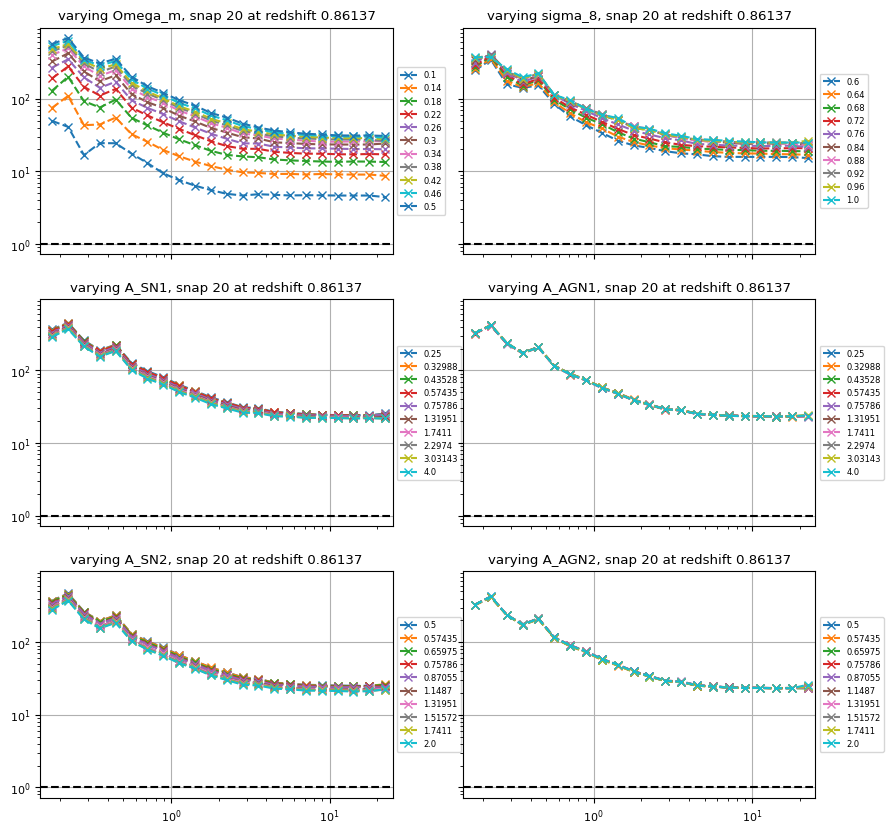

In [10]:
make_plots_for_all_paras(snap_index=20)

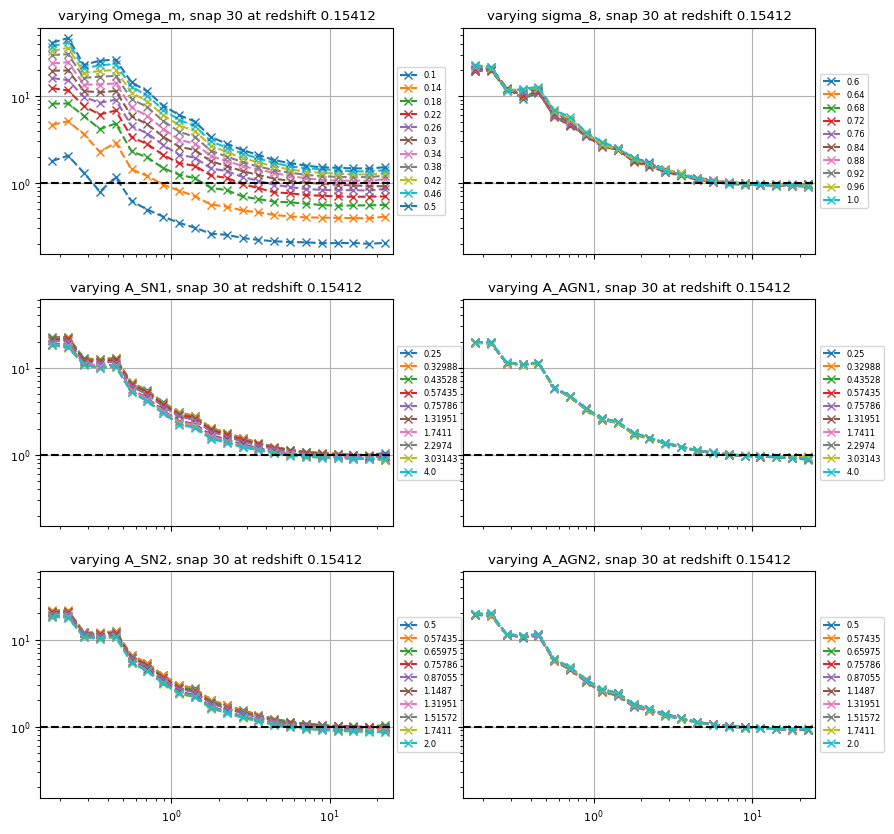

In [11]:
make_plots_for_all_paras(snap_index=30)